In [38]:
import datetime
import numpy as np
import sys
import time
import os
from os.path import join
from matplotlib import pyplot as pl

sys.path.append('../')
import paraPropPython as ppp
from receiver import receiver
from data import bscan, ascan
from permittivity import southpole
import util
from transmitter import tx_signal

data_mode = True

/home/alxok/miniconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alxok/miniconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


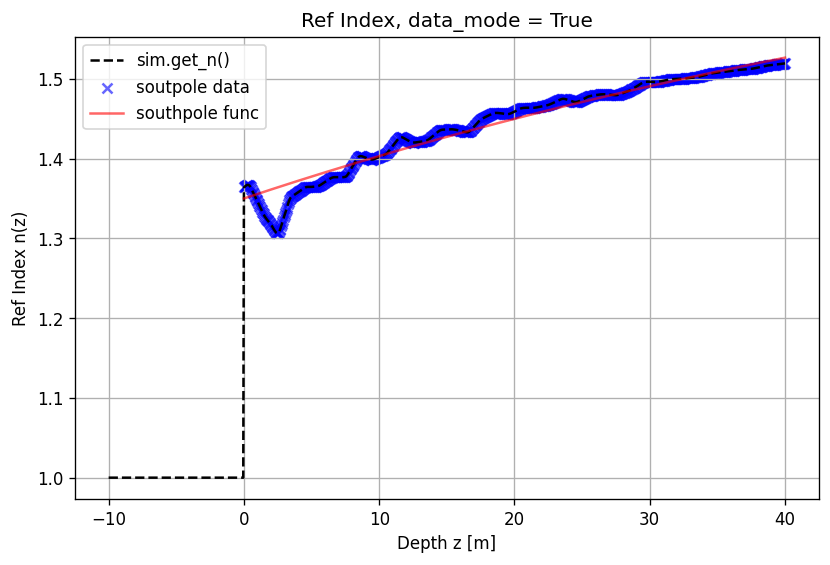

In [39]:
#Define Geometry

iceDepth = 40. # iceDepth (make sure this is less than or equal to the maximum depth of your ref. index model)
iceLength = 100.

dx = 1.0 #Range resolution [m]
dz = 0.05 #Depth resolution [m]
airHeight = 10. #Air Height

#Define Signal properties
# This is signal is an impulse run through a bandpass filter
freq = 0.2 # Central frequency of dipole antenna
fmin = 0.05 # Minimum Frequency (Highpass cut)
fmax = 0.3 # Maximum Frequnecy (Lowpass cut)
band = fmax-fmin # Bandwidth of pulse
t_centre = 10. # Time where impulse = 1
dt = 1 # Timing resolution - inverse of sample frequency
t_max = 3 * 1.8 * iceLength/0.3 # Size of time domain

# Path to the saved data
path2data = 'ascan_dir_2D'
if os.path.isdir(path2data) == False:
    os.system('mkdir ' + path2data)

# Set up Receiver array (rxList)
d_rx = 2 #spacing between receivers (for x and z)
rx_ranges = np.arange(d_rx, iceLength, d_rx) # Receiver ranges
rx_depths = np.arange(d_rx, iceDepth, d_rx) # Receiver depths

#Define Ice Model (1D):
# Set up a dummy simulation object - to get array sizes

sim0 = ppp.paraProp(iceLength=iceLength, iceDepth=iceDepth, dx=dx, dz=dz, airHeight=airHeight)
n_prof_data, z_prof_data = util.get_profile_from_file_cut('../share/spice2019_indOfRef_core1_5cm.txt', 0, iceDepth) 

if data_mode == True:
    sim0.set_n(nVec=n_prof_data, zVec=z_prof_data)
else:
    sim0.set_n(nFunc=southpole)

x = sim0.x # Simulation range vector (0 to iceLength, by dx)
z = sim0.z # Simulation depth vector (-airHeight to iceDepth, by dz)
zFull = sim0.zFull # Simulation full depth vector, which is the depth vector + 2xfilterDepth i.e. includes absorbing layer
xNum = sim0.xNum # Size of range vector x=sim0.x
zNum = sim0.zNum # Size of depth vector z = sim0.z
zNumFull = sim0.zNumFull # Size of full-depth vector, zFull = sim0.zFull

fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
ax.set_title('Ref Index, data_mode = ' + str(data_mode))
ax.plot(z, sim0.get_n(x=0), '--',c='k',label= 'sim.get_n()')
ax.scatter(z_prof_data, n_prof_data, marker='x', c='b', label='soutpole data',alpha=0.6)

ii0 = util.findNearest(sim0.get_z(), 0)
z_cut = z[ii0:]

ax.plot(z_cut, southpole(z_cut),c='r',label='southpole func',alpha=0.6)
ax.set_ylabel('Ref Index n(z)')
ax.set_xlabel('Depth z [m]')
ax.legend()
ax.grid()
pl.show()

In [45]:
#Depth soure vector i.e. list of source depths
tx_depths = [10, 30]
nTx = len(tx_depths)

tx_signal0 = tx_signal(frequency=freq, bandwidth=band, t_centre=t_centre, dt=dt, tmax=t_max, amplitude=1)
tx_signal0.set_impulse()
tx_signal0.apply_bandpass(fmin=fmin, fmax=fmax)

fname_out = 'ascan_example_Xice_' + str(iceLength) + '_Zice_' + str(iceDepth) + '.h5'
fname_out = join(path2data, fname_out)

if nTx == 0:
    for j in range(nTx):
        sourceDepth = tx_depths[j]
        print('z_tx = ', sourceDepth, 'm')

        
        tx_pulse = tx_signal0.pulse.real
        tspace = tx_signal0.tspace
    
        rxList = []
        for x in rx_ranges:
            for z in rx_depths:
                rx_ij = receiver(x=x, z=z)
                rxList.append(rx_ij)
        
        sim = ppp.paraProp(iceLength=iceLength, iceDepth=iceDepth, dx=dx, dz=dz, airHeight=airHeight)
        if data_mode == True:
            sim.set_n(nVec=n_prof_data, zVec=z_prof_data)
        else:
            sim.set_n(nFunc=southpole)
        sim.set_dipole_source_profile(centerFreq=freq, depth=sourceDepth)
        sim.set_td_source_signal(sigVec=tx_pulse, dt=dt)
        tstart = time.time()
        sim.do_solver(rxList)
        tend = time.time()
    
        duration = tend - tstart
        print('Solution time:')
        print(datetime.timedelta(seconds=duration))
    
        ascan_1 = ascan()
        ascan_1.save_sim_to_hdf(sim=sim,
                                tx_signal_in=tx_signal0,
                                rxList=rxList,
                                sourceDepth=sourceDepth,
                                fname_hdf=fname_out)
else:
    for j in range(nTx):
        sourceDepth = tx_depths[j]
        print('z_tx = ', sourceDepth, 'm')
        tx_pulse = tx_signal0.pulse.real
        tspace = tx_signal0.tspace
        rxList = []
        for x in rx_ranges:
            for z in rx_depths:
                rx_ij = receiver(x=x, z=z)
                rxList.append(rx_ij)
        
        sim = ppp.paraProp(iceLength=iceLength, iceDepth=iceDepth, dx=dx, dz=dz, airHeight=airHeight)
        if data_mode == True:
            sim.set_n(nVec=n_prof_data, zVec=z_prof_data)
        else:
            sim.set_n(nFunc=southpole)
        sim.set_dipole_source_profile(centerFreq=freq, depth=sourceDepth)
        sim.set_td_source_signal(sigVec=tx_pulse, dt=dt)
        tstart = time.time()
        sim.do_solver(rxList)
        tend = time.time()
    
        duration = tend - tstart
        print('Solution time:')
        print(datetime.timedelta(seconds=duration))
    
        if j == 0:
            ascan_1 = ascan()
            ascan_1.save_sim_to_hdf_init(sim=sim,
                                         tx_signal_in=tx_signal0,
                                         rxList=rxList,
                                         tx_depths=tx_depths,
                                         ii_tx = j,
                                         fname_hdf=fname_out)
        else:
            ascan_1.save_sim_to_hdf_append(rxList=rxList, z_tx=sourceDepth, fname_hdf=fname_out)

nHalf =  900
z_tx =  10 m
1.0691218572804106 0.05
[0.        +0.j 0.34906585+0.j 0.6981317 +0.j 1.04719755+0.j
 1.3962634 +0.j 1.74532925+0.j 2.0943951 +0.j 2.44346095+0.j
 2.7925268 +0.j 3.14159265+0.j 3.14159265+0.j 2.7925268 +0.j
 2.44346095+0.j 2.0943951 +0.j 1.74532925+0.j 1.3962634 +0.j
 1.04719755+0.j 0.6981317 +0.j 0.34906585+0.j 0.        +0.j]
one-way
Solution time:
0:00:45.987062
z_tx =  30 m
1.0018194273645937 0.05
[0.        +0.j 0.34906585+0.j 0.6981317 +0.j 1.04719755+0.j
 1.3962634 +0.j 1.74532925+0.j 2.0943951 +0.j 2.44346095+0.j
 2.7925268 +0.j 3.14159265+0.j 3.14159265+0.j 2.7925268 +0.j
 2.44346095+0.j 2.0943951 +0.j 1.74532925+0.j 1.3962634 +0.j
 1.04719755+0.j 0.6981317 +0.j 0.34906585+0.j 0.        +0.j]
one-way
Solution time:
0:00:49.063879
Saving data at z_tx = 30, index = 1


In [46]:
# An example of the results
ascan_2 = ascan()
ascan_2.load_from_hdf(fname_hdf=fname_out)

nHalf =  900


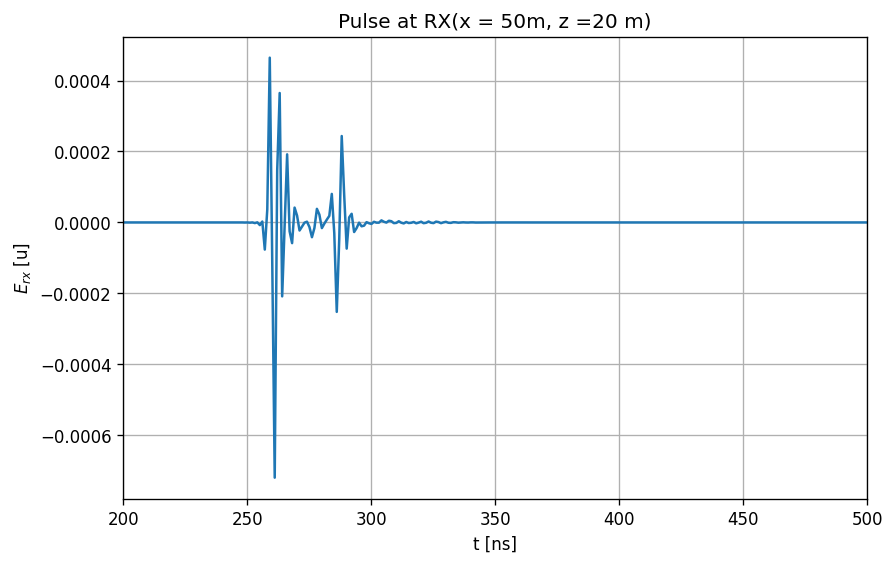

In [47]:
# An example of receiver waveform
x_rx_ex = 50
z_rx_ex = 20
z_tx_ex = tx_depths[0]

tspace = ascan_2.tspace
pulse_rx = ascan_2.get_ascan(z_tx=z_tx_ex, x_rx=x_rx_ex, z_rx=z_rx_ex)

fig = pl.figure(figsize=(8,5),dpi=120)
ax = fig.add_subplot(111)
ax.plot(tspace, pulse_rx)
ax.set_xlim(200, 500)
ax.set_title('Pulse at RX(x = ' + str(x_rx_ex) + 'm, z =' + str(z_rx_ex) + ' m)')
ax.set_ylabel('$E_{rx}$ [u]')
ax.set_xlabel('t [ns]')
ax.grid()
pl.show()